# Planning Multiple Experiments with Pyomo.DoE

Multi-experiment design is useful when several experiments can be run in parallel. Instead of designing one experiment at a time, we optimize multiple experiments together so that they provide complementary information about the model parameters. In Pyomo.DoE, this is done by maximizing a scalar function of the sum of the Fisher information matrices from each experiment, together with any prior information.

Maximize a scalar-valued function $\psi(\cdot)$ of the sum of the Fisher information matrices $\mathbf{M}$:
$$
\begin{align*}
\max_{u_1,.., u_{N_{exp}}} \quad & \psi \left(\mathbf{M}_0+ \sum_{k\in E}\mathbf{M}_k(u_k)\right) \\
\mathrm{s.t.} \quad & C_p^H \frac{dT_{H,k}}{dt} = U_a (T_{amb, k} - T_{H, k}) + U_b (T_{S,k} - T_{H,k}) + \alpha P u_k(t); \; \forall k \in E\\
& C_p^S \frac{dT_{S, k}}{dt} = U_b (T_{H,k} - T_{S,k}); \; \forall k \in E \\
& 0\% \leq u_k(t) \leq 100 \%; \; \forall k \in E\\
& T_{H,k}(t_0) = T_{amb, k}; \; \forall k \in E\\
& T_{S, k}(t_0) = T_{amb, k}; \; \forall k \in E
\end{align*}
$$
Here, $E=\{1, 2, ..., N_{exp}\}$ is the set of experiments in the experimental campaign.
For multi-experiment design, `Pyomo.DoE` automatically formulates, initializes, and solves this optimization problem for the following optimality criteria: 
- Maximizing $\log_{10}(\mathrm{trace (FIM)})$, i.e., Pseudo A-optimality 
- Minimizing $\log_{10}(\mathrm{trace (FIM^{-1})})$, i.e., A-optimality, 
- Maximizing $\log_{10}(\mathrm{det (FIM)})$, i.e., D-optimality.
- Maximizing $\log_{10}(\mathrm{min\; eigenvalue (FIM)})$, i.e., E-optimality.
- Minimizing $\log_{10}(\mathrm{condition\; number (FIM)})$, i.e., ME-optimality.

For documentation follow the [Pyomo documentation page](https://pyomo.readthedocs.io/en/stable/explanation/analysis/doe/doe.html).

## Import necessary functions for the two-state TC Lab model

In [1]:
import sys

# If running on Google Colab, install Pyomo and Ipopt via IDAES
on_colab = "google.colab" in sys.modules
if on_colab:
    !wget "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/notebooks/tclab_pyomo.py"

# import TCLab model, simulation, and data analysis functions
from tclab_pyomo import (
    TC_Lab_data,
    TC_Lab_experiment,
    extract_plot_results,
    results_summary,
)

# set default number of states in the TCLab model
number_tclab_states = 2

## Load experimental data (sine test)
We will load the sine test experimental data to serve as an initial point. 

In [2]:
import pandas as pd

if on_colab:
    file = "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/data/tclab_sine_test_5min_period.csv"
else:
    file = '../data/tclab_sine_test_5min_period.csv'
df = pd.read_csv(file)
df.head()

,Time,T1,T2,Q1,Q2
0,0.00,22.2,22.2,50,0
1,1.01,22.2,22.2,51,0
2,2.01,22.2,22.2,52,0
3,3.00,22.2,22.2,53,0
4,4.01,22.2,22.2,54,0


## Use prior parameter information
We will use the parameter estimates and covariance matrix obtained in the previous notebook. Since the Fisher information matrix (FIM) is the inverse of the covariance matrix, we can use that result as prior information for the new design problem.

In [3]:
import numpy as np
# Load Pyomo.DoE class
from pyomo.contrib.doe import DesignOfExperiments
from pyomo.environ import SolverFactory

# Theta values estimated from the regularized regresssion in the previous notebook
# L2 regularization
theta_values = {
    'Ua': 0.041705,
    'Ub': 0.012009,
    'inv_CpH': 0.167457,
    'inv_CpS': 4.545432,
}

# Cov estimated from the regularized regression in the previous notebook
# L2 regularization
cov = np.array([[1.857017e-10, -2.576198e-10, 1.402148e-09, -2.242347e-12],
               [-2.576198e-10, 1.624383e-07, 9.109870e-08, -6.325555e-05],
               [1.402148e-09, 9.109870e-08, 1.031454e-07, -3.890789e-05],
               [-2.242347e-12, -6.325555e-05, -3.890789e-05, 2.499914e-02]]
               )

PRIOR_FIM = np.linalg.inv(cov)
results_summary(PRIOR_FIM)

======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 9.910298890895081
A-optimality: -1.6020703142934263
D-optimality: 27.781982236650098
E-optimality: 1.6020710987913134
Modified E-optimality: 8.254407420205586

FIM:
 [[ 7.17766325e+09  1.00811757e+08 -2.18902252e+08 -8.56071665e+04]
 [ 1.00811757e+08  8.99331580e+08  1.51888631e+08  2.51198161e+06]
 [-2.18902252e+08  1.51888631e+08  5.68992000e+07  4.72881315e+05]
 [-8.56071665e+04  2.51198161e+06  4.72881315e+05  7.13206905e+03]]

eigenvalues:
 [7.18585615e+09 9.25285788e+08 2.27591861e+07 4.00010230e+01]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua         0.9994    0.0098    0.0326   -0.0000
Ub         0.0153   -0.9846   -0.1743   -0.0025
inv_CpH   -0.0304   -0.1747    0.9842   -0.0016
inv_CpS   -0.0000   -0.0028    0.0011    1.0000


In [4]:
from pyomo.contrib.doe.utils import rescale_FIM

theta_ref = np.array(
    [
        theta_values["Ua"],
        theta_values["Ub"],
        theta_values["inv_CpH"],
        theta_values["inv_CpS"],
    ]
)
# Because the parameter values differ substantially in magnitude, we can use parameter
# scaling in DesignOfExperiments to improve numerical conditioning.
SCALE_BY_NOMINAL_PARAM = True
SCALE_CONSTANT_VALUE = 1e-2
if SCALE_BY_NOMINAL_PARAM:
    PRIOR_FIM_SCALED = rescale_FIM(PRIOR_FIM, theta_ref) * SCALE_CONSTANT_VALUE**2
else:
    PRIOR_FIM_SCALED = PRIOR_FIM * SCALE_CONSTANT_VALUE**2

## Initialize two experiments
We now create two experiment objects. The first uses the measured sine-test data, and the second uses a different initial input profile so that the optimizer can optimize both experiments simultaneously.

In [5]:
# Create the first experiment object
skip = 20

# Create the data object considering the new control points every 15 seconds
tc_data_1 = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values[::skip],
    T1=df['T1'].values[::skip],
    u1=df['Q1'].values[::skip],
    P1=200,
    TS1_data=None,
    T2=df['T2'].values[::skip],
    u2=df['Q2'].values[::skip],
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)

# Create experiment object for design of experiments
doe_experiment_1 = TC_Lab_experiment(
    data=tc_data_1,
    theta_initial=theta_values,
    number_of_states=number_tclab_states,
)

In [6]:
# Create the second experiment object
from dataclasses import replace

# Set a random seed for reproducibility
SEED: int = 11 # Choose any integer seed you like
PDF = "normal" # Choose between "normal" or "uniform" distribution for the new design of u1


def get_initial_u1_design(PDF="uniform", seed=11, sample_data = tc_data_1):
    rng = np.random.default_rng(seed=seed)
    if PDF == "normal":
        u1_design = rng.normal(loc=50.0, scale=10.0, size=len(sample_data.time))
        # Normal distribution is unbounded, so we need to clip the values to be within the 
        # bounds of the control input, which is [0, 100] in this case.
        u1_design = np.clip(u1_design, 0.0, 100.0)    
    elif PDF == "uniform":
        u1_design = rng.uniform(low=0.0, high=100.0, size=len(sample_data.time))

    # To break permutation symmetry, we can enforce that the first value of u1_design 
    # is greater than the first value of the original u1 data.
    if u1_design[0] <= sample_data.u1[0] and sample_data.u1[0] < 90.0:
        u1_design[0] = sample_data.u1[0] + 10.0
    else:
        u1_design[0] = 100.0

    # Create a new data object with only u1 replaced
    tc_data_new = replace(sample_data, u1=u1_design)
    return tc_data_new


tc_data_2 = get_initial_u1_design(PDF=PDF, seed=SEED, sample_data=tc_data_1)
# Build the experiment with the new design variable
doe_experiment_2 = TC_Lab_experiment(
    data=tc_data_2,
    theta_initial=theta_values,
    number_of_states=number_tclab_states,
)

## Optimize two experiments (D-optimality)
We now create a `DesignOfExperiments` object for the two experiments and choose a `D-optimality` objective. We also pass prior_FIM, which represents information already available from previous parameter estimation.

In [7]:
# Add a solver object to pass to DesignOfExperiments
solver = SolverFactory("ipopt")
solver.options["max_iter"] = 3000
solver.options["tol"] = 1e-5
solver.options["linear_solver"] = "ma57"
solver.options["nlp_scaling_method"] = "gradient-based"

In [8]:
# Create the `design of experiments` object using our experiment instance from above
SCALE_CONSTANT_VALUE = 1e-2
TC_Lab_DoE_D = DesignOfExperiments(
    experiment=[doe_experiment_1, doe_experiment_2],
    # We are optimizing two experiments simultaneously!
    step=1e-2,
    scale_constant_value=SCALE_CONSTANT_VALUE,
    scale_nominal_param_value=SCALE_BY_NOMINAL_PARAM,
    objective_option="determinant",
    # Now we specify a type of objective, D-opt = "determinant"
    prior_FIM=PRIOR_FIM_SCALED,
    tee=True,
    solver=solver,
)


# Optimize the experimental design
TC_Lab_DoE_D.optimize_experiments()

Ipopt 3.13.2: max_iter=3000
tol=1e-05
linear_solver=ma57
nlp_scaling_method=gradient-based


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection

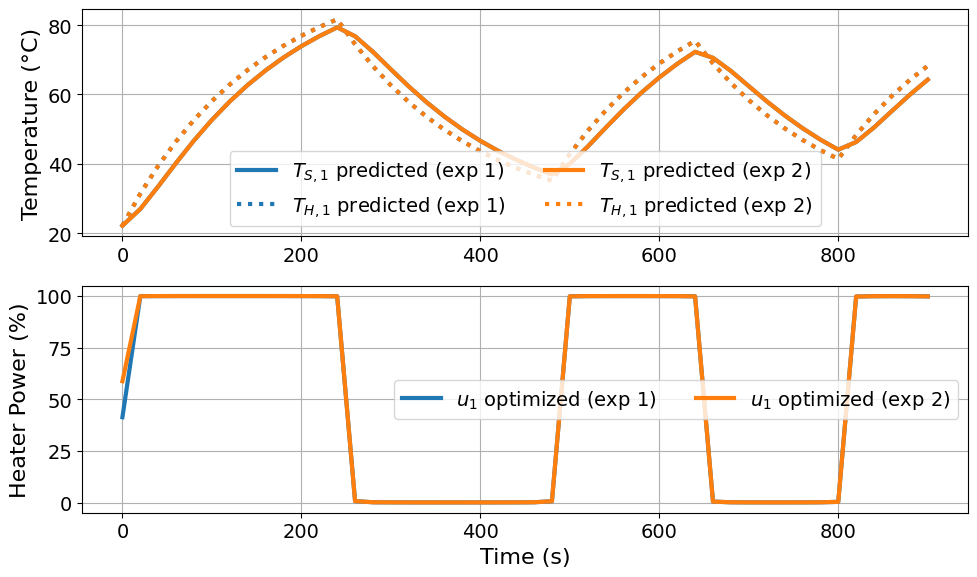

In [9]:
multiexp_results = extract_plot_results(None, TC_Lab_DoE_D)

Interesting! we get a piecewise constant with ramp like change in the design (heater power). The designs are quite similar in shape. Since the log10 D-optimality of the prior is already very high, it is very hard to find new experiments that can give us more information. 

In [10]:
FIM_D = np.asarray(TC_Lab_DoE_D.results["solution"]["param_scenarios"][0]['total_fim'])
if SCALE_BY_NOMINAL_PARAM:
    D = np.diag(theta_ref)
    FIM_unscaled_D = D @ FIM_D @ D / SCALE_CONSTANT_VALUE**2
else:
    FIM_unscaled_D = FIM_D / SCALE_CONSTANT_VALUE**2
results_summary(np.asarray(FIM_unscaled_D))

======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 9.910321171874886
A-optimality: -5.6024274672055725
D-optimality: 31.79039252778086
E-optimality: 5.610348353368276
Modified E-optimality: 4.24613030945625

FIM:
 [[ 7.17766556e+09  1.00811757e+08 -2.18903291e+08 -8.67139679e+04]
 [ 1.00811757e+08  8.99331582e+08  1.51888727e+08  2.51297016e+06]
 [-2.18903291e+08  1.51888727e+08  5.69063038e+07  5.16075520e+05]
 [-8.67139679e+04  2.51297016e+06  5.16075520e+05  4.15024062e+05]]

eigenvalues:
 [7.18585853e+09 9.25286094e+08 2.27661439e+07 4.07707174e+05]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua        -0.9994   -0.0098   -0.0326   -0.0001
Ub        -0.0153    0.9846    0.1743   -0.0022
inv_CpH    0.0304    0.1747   -0.9842   -0.0034
inv_CpS    0.0000    0.0028   -0.0030    1.0000


### Compare the reduction in predicted uncertainty

In [11]:
# Helper function to print parameter values with their standard deviations
def param_std(
    std: np.ndarray,
    parameters: dict = theta_values,
):
    for i, key in enumerate(parameters.keys()):
        print(f"{key}: {parameters[key]:.3e} ± {std[i]:.3e}")

In [12]:
# Now compare the uncertainty for the prior and the optimized design to see how much
# improvement we have achieved in terms of parameter uncertainty reduction.
cov_D = np.linalg.inv(FIM_unscaled_D)
std_D = np.sqrt(np.diag(cov_D))
std_prior = np.sqrt(np.diag(cov))
print("Parameter estimates with standard deviations for the prior:")
param_std(std_prior)

print(
    "\nParameter estimates with predicted standard deviations for the optimized design:"
)
param_std(std_D)

Parameter estimates with standard deviations for the prior:
Ua: 4.170e-02 ± 1.363e-05
Ub: 1.201e-02 ± 4.030e-04
inv_CpH: 1.675e-01 ± 3.212e-04
inv_CpS: 4.545e+00 ± 1.581e-01

Parameter estimates with predicted standard deviations for the optimized design:
Ua: 4.170e-02 ± 1.363e-05
Ub: 1.201e-02 ± 4.893e-05
inv_CpH: 1.675e-01 ± 2.064e-04
inv_CpS: 4.545e+00 ± 1.566e-03


## Activity: Repeat the design with A-optimality
In this activity, we repeat the same workflow as above but change only the design objective. The repeated setup is shown again here so the section can be run independently.

In [13]:
# Create the design of experiments object using our experiment instance from above
TC_Lab_DoE_A = DesignOfExperiments(
    experiment=[
        doe_experiment_1,
        doe_experiment_2,
    ],  # We are optimizing two experiments simultaneously!
    step=1e-2,
    scale_constant_value=SCALE_CONSTANT_VALUE,
    scale_nominal_param_value=SCALE_BY_NOMINAL_PARAM,
    objective_option="trace",  # Now we specify a type of objective, D-opt = "determinant"
    prior_FIM=PRIOR_FIM_SCALED,  # We use the prior information from the existing experiment!
    tee=True,
    solver=solver,
)

TC_Lab_DoE_A.optimize_experiments()

Ipopt 3.13.2: max_iter=3000
tol=1e-05
linear_solver=ma57
nlp_scaling_method=gradient-based


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection

### Analyze the results

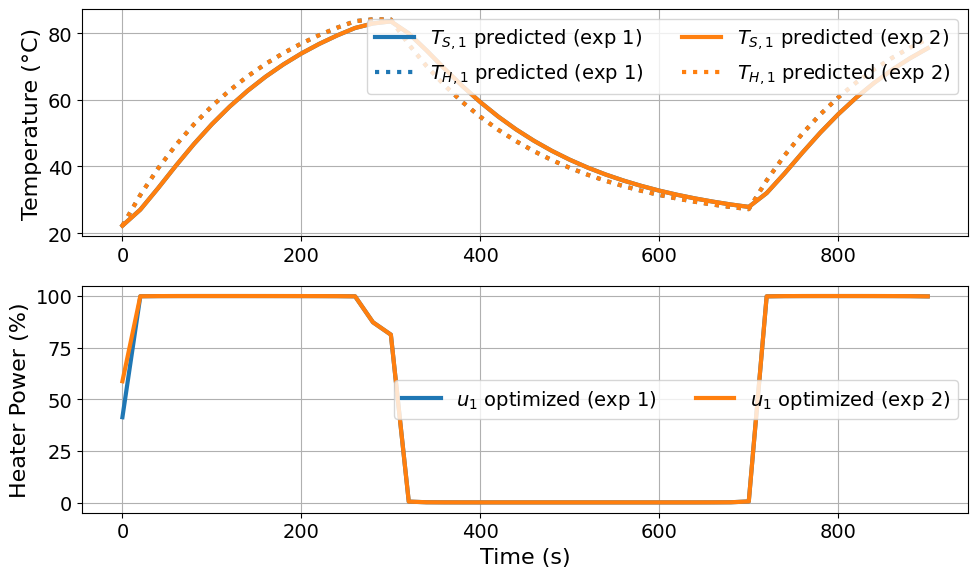

In [14]:
multiexp_results = extract_plot_results(None, TC_Lab_DoE_A)

Depending on whether you used parameter scaling in the DesignOfExperiments

In [15]:
FIM_A = np.asarray(TC_Lab_DoE_A.results["solution"]["param_scenarios"][0]['total_fim'])

if SCALE_BY_NOMINAL_PARAM:
    D = np.diag(theta_ref)
    FIM_unscaled_A = D @ FIM_A @ D / SCALE_CONSTANT_VALUE**2
else:
    FIM_unscaled_A = FIM_A / SCALE_CONSTANT_VALUE**2
results_summary(np.asarray(FIM_unscaled_A))

======Results Summary======
Five design criteria log10() value:
Pseudo A-optimality: 9.910323270177928
A-optimality: -5.6387268309537735
D-optimality: 31.827447917165255
E-optimality: 5.647343948359023
Modified E-optimality: 4.2091347020252305

FIM:
 [[ 7.17766536e+09  1.00811757e+08 -2.18903297e+08 -8.66459853e+04]
 [ 1.00811757e+08  8.99331582e+08  1.51888759e+08  2.51302321e+06]
 [-2.18903297e+08  1.51888759e+08  5.69094480e+07  5.31015876e+05]
 [-8.66459853e+04  2.51302321e+06  5.31015876e+05  4.51390388e+05]]

eigenvalues:
 [7.18585832e+09 9.25286216e+08 2.27692762e+07 4.43960108e+05]

Eigenvector matrix:
          eigvec_1  eigvec_2  eigvec_3  eigvec_4
Ua        -0.9994   -0.0098   -0.0326   -0.0001
Ub        -0.0153    0.9846    0.1743   -0.0021
inv_CpH    0.0304    0.1747   -0.9841   -0.0041
inv_CpS    0.0000    0.0028   -0.0037    1.0000


In [17]:
# Now compare the uncertainty for the prior and the optimized design to see how much
# improvement we have achieved in terms of parameter uncertainty reduction.
std_D = np.sqrt(np.diag(cov_D))
std_A = np.sqrt(np.diag(np.linalg.inv(FIM_unscaled_A)))
print("Parameter estimates with standard deviations for D-optimal design:")
param_std(std_D)

print("\nParameter estimates with standard deviations for A-optimal design:")
param_std(std_A)

Parameter estimates with standard deviations for D-optimal design:
Ua: 4.170e-02 ± 1.363e-05
Ub: 1.201e-02 ± 4.893e-05
inv_CpH: 1.675e-01 ± 2.064e-04
inv_CpS: 4.545e+00 ± 1.566e-03

Parameter estimates with standard deviations for A-optimal design:
Ua: 4.170e-02 ± 1.363e-05
Ub: 1.201e-02 ± 4.890e-05
inv_CpH: 1.675e-01 ± 2.064e-04
inv_CpS: 4.545e+00 ± 1.501e-03


**Discussion**: How does changing the `objective` change the result? Which one is better for reducing the uncertainty in our experiment?